# DEEP LEARNING PROJECT: MEDICAL IMAGE SEGMENTATION WITH LIMITED TRAINING DATA
## Benchmark Case Study: Lung Boundary Segmentation on Chest X-Rays

> **Course:** Deep Learning  
> **Domain:** Computer Vision / Medical AI  
> **Anatomical Target:** Both lungs (Left Lung & Right Lung) on Chest X-Rays (CXR)  
> **Primary Execution Environment:** **Google Colab (Tesla T4 GPU - 15GB VRAM)**  

### 1. Verify GPU Hardware Configuration on Google Colab

In [1]:
!nvidia-smi


Tue Oct  6 01:35:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 2. Install Required Deep Learning Libraries

In [2]:
!pip install -q segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


### 3. Download and Extract Chest X-Ray Lung Segmentation Dataset
> **Instructions:** High-speed direct automated dataset download via the Kaggle API.

In [3]:
import os
# Configure Kaggle API Token directly
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f7482e190c33e3602fd6384906ccacbc"

# Download and unzip dataset from Kaggle (~50MB/s)
if not os.path.exists("Lung Segmentation"):
    print(">>> Downloading dataset from Kaggle...")
    !kaggle datasets download -d nikhilpandey360/chest-xray-masks-and-labels --unzip
    print(">>> Dataset extracted successfully!")
else:
    print(">>> Dataset already exists on Colab!")


>>> Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/nikhilpandey360/chest-xray-masks-and-labels
License(s): CC0-1.0
100% 9.58G/9.58G [01:50<00:00, 93.3MB/s]

>>> Dataset extracted successfully!


### 4. Scan and Prepare Dataset Splits
* Fixed independent **Test set: 20% (140 images)**.
* Fixed **Validation set: 84 images**.
* Nested training sub-splits: **5% (24 images), 10% (48 images), 25% (120 images), 50% (240 images), 100% (480 images)**.

In [4]:
import os
import random
import pandas as pd
from pathlib import Path

def prepare_splits(data_dir='Lung Segmentation', output_dir='splits', test_ratio=0.20, seed=42):
    os.makedirs(output_dir, exist_ok=True)
    random.seed(seed)

    cxr_dir = os.path.join(data_dir, 'CXR_png')
    mask_dir = os.path.join(data_dir, 'masks')
    mask_files = set(os.listdir(mask_dir))

    pairs = []
    for f in os.listdir(cxr_dir):
        if not f.endswith('.png'):
            continue
        dataset_type = 'unknown'
        mask_name = None
        if f.startswith('MCUCXR') and f in mask_files:
            dataset_type = 'Montgomery'
            mask_name = f
        elif f.startswith('CHNCXR'):
            target_mask = f.replace('.png', '_mask.png')
            if target_mask in mask_files:
                dataset_type = 'Shenzhen'
                mask_name = target_mask

        if mask_name is not None:
            pairs.append({
                'filename': f,
                'dataset': dataset_type,
                'image_path': os.path.join(cxr_dir, f),
                'mask_path': os.path.join(mask_dir, mask_name)
            })

    mcu = [p for p in pairs if p['dataset'] == 'Montgomery']
    chn = [p for p in pairs if p['dataset'] == 'Shenzhen']
    random.shuffle(mcu)
    random.shuffle(chn)

    n_test_mcu = int(len(mcu) * test_ratio)
    n_test_chn = int(len(chn) * test_ratio)

    test_pool = mcu[:n_test_mcu] + chn[:n_test_chn]
    train_val_pool = mcu[n_test_mcu:] + chn[n_test_chn:]
    random.shuffle(test_pool)
    random.shuffle(train_val_pool)

    n_val = int(len(train_val_pool) * 0.15)
    val_pool = train_val_pool[:n_val]
    train_full = train_val_pool[n_val:]

    pd.DataFrame(test_pool).to_csv(os.path.join(output_dir, 'test_fixed_20pct.csv'), index=False)
    pd.DataFrame(val_pool).to_csv(os.path.join(output_dir, 'val_fixed.csv'), index=False)

    shuffled_train = list(train_full)
    random.shuffle(shuffled_train)

    ratios = {
        'train_5pct.csv': 0.05,
        'train_10pct.csv': 0.10,
        'train_25pct.csv': 0.25,
        'train_50pct.csv': 0.50,
        'train_100pct.csv': 1.00
    }
    for filename, ratio in ratios.items():
        n = max(2, int(len(shuffled_train) * ratio))
        pd.DataFrame(shuffled_train[:n]).to_csv(os.path.join(output_dir, filename), index=False)

    print(f'Total valid pairs: {len(pairs)}')
    print(f'Test: {len(test_pool)} | Val: {len(val_pool)} | Train 100%: {len(train_full)}')
    for f, r in ratios.items():
        print(f'  -> {f}: {max(2, int(len(shuffled_train) * r))} samples')

prepare_splits()


Total valid pairs: 704
Test: 140 | Val: 84 | Train 100%: 480
  -> train_5pct.csv: 24 samples
  -> train_10pct.csv: 48 samples
  -> train_25pct.csv: 120 samples
  -> train_50pct.csv: 240 samples
  -> train_100pct.csv: 480 samples


### 5. Build PyTorch Dataset & Data Augmentation Pipeline
Applies spatial and photometric augmentations (flips, affine transformations, brightness/contrast adjustments).

In [5]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transforms(img_size=256, is_train=True):
    if is_train:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.Affine(scale=(0.9, 1.1), rotate=(-15, 15), translate_percent=(-0.0625, 0.0625), p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

class LungDataset(Dataset):
    def __init__(self, csv_file, img_size=256, is_train=True):
        self.df = pd.read_csv(csv_file)
        self.transforms = get_transforms(img_size=img_size, is_train=is_train)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        augmented = self.transforms(image=image, mask=mask)
        image = augmented['image']
        mask = augmented['mask']
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        return image, mask, row['filename']

def get_loader(csv_file, img_size=256, batch_size=8, is_train=True):
    ds = LungDataset(csv_file, img_size=img_size, is_train=is_train)
    return DataLoader(ds, batch_size=batch_size, shuffle=is_train, num_workers=2, pin_memory=True)


### 6. Model Architectures (Vanilla U-Net vs Pretrained U-Net) & Compound Loss
* **Vanilla U-Net:** 4-stage resolution encoder-decoder trained from scratch.
* **Pretrained U-Net:** ResNet-34 encoder pretrained on ImageNet.
* **Compound Loss:** Combination of Binary Cross-Entropy (BCE) and Dice Loss.

In [6]:
import torch.nn as nn
import segmentation_models_pytorch as smp

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class VanillaUNet(nn.Module):
    def __init__(self, in_channels=3, classes=1, base=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base)
        self.d1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base, base*2))
        self.d2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.d3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))
        self.d4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*8, base*16))

        self.up1 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.c1 = DoubleConv(base*16, base*8)
        self.up2 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.c2 = DoubleConv(base*8, base*4)
        self.up3 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.c3 = DoubleConv(base*4, base*2)
        self.up4 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.c4 = DoubleConv(base*2, base)
        self.outc = nn.Conv2d(base, classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.d1(x1)
        x3 = self.d2(x2)
        x4 = self.d3(x3)
        x5 = self.d4(x4)
        x = self.c1(torch.cat([x4, self.up1(x5)], dim=1))
        x = self.c2(torch.cat([x3, self.up2(x)], dim=1))
        x = self.c3(torch.cat([x2, self.up3(x)], dim=1))
        x = self.c4(torch.cat([x1, self.up4(x)], dim=1))
        return self.outc(x)

def build_model(model_name='unet', encoder='resnet34'):
    if model_name == 'vanilla_unet':
        return VanillaUNet(in_channels=3, classes=1)
    return smp.Unet(encoder_name=encoder, encoder_weights='imagenet', in_channels=3, classes=1)

class ComboLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        inter = (p * t).sum()
        dice = (2. * inter + 1e-6) / (p.sum() + t.sum() + 1e-6)
        return 0.5 * bce + 0.5 * (1. - dice)

@torch.no_grad()
def compute_dice_iou(logits, targets):
    preds = (torch.sigmoid(logits) > 0.5).float().view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2. * inter + 1e-6) / (union + 1e-6)
    iou = (inter + 1e-6) / (union - inter + 1e-6)
    return dice.mean().item(), iou.mean().item()


### 7. Training & Evaluation Engine
Integrates AdamW optimization, CosineAnnealingLR scheduling, and checkpointing on best validation Dice score.

In [7]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_and_eval(model_name, encoder, ratio_pct, epochs=25, batch_size=8, lr=3e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_loader = get_loader(f'splits/train_{ratio_pct}pct.csv', batch_size=batch_size, is_train=True)
    val_loader = get_loader('splits/val_fixed.csv', batch_size=batch_size, is_train=False)
    test_loader = get_loader('splits/test_fixed_20pct.csv', batch_size=batch_size, is_train=False)

    model = build_model(model_name, encoder).to(device)
    criterion = ComboLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_dice = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        model.train()
        for imgs, masks, _ in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        dices = []
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                d, _ = compute_dice_iou(model(imgs), masks)
                dices.append(d)
        val_dice = sum(dices) / len(dices)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_weights = model.state_dict().copy()

    # Evaluate on independent Test set
    model.load_state_dict(best_weights)
    model.eval()
    test_dices, test_ious = [], []
    with torch.no_grad():
        for imgs, masks, _ in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            d, i = compute_dice_iou(model(imgs), masks)
            test_dices.append(d)
            test_ious.append(i)

    test_dice = sum(test_dices) / len(test_dices)
    test_iou = sum(test_ious) / len(test_ious)
    print(f'[{model_name.upper()} | Ratio: {ratio_pct:3d}%] -> Test Dice: {test_dice*100:.2f}% | Test IoU: {test_iou*100:.2f}%')
    # Save checkpoint for qualitative visualization
    os.makedirs('checkpoints', exist_ok=True)
    if best_weights is not None:
        torch.save(best_weights, f'checkpoints/{model_name}_{ratio_pct}pct.pth')
    return test_dice, test_iou


### 8. Run Full Data Scaling Benchmark (5%, 10%, 25%, 50%, 100%)
> Trains and evaluates all 10 experimental configurations on the fixed test set.

In [8]:
ratios = [5, 10, 25, 50, 100]
results = []

print('=== 1. TRAINING PRETRAINED U-NET (RESNET-34) ===')
for r in ratios:
    dice, iou = train_and_eval('unet', 'resnet34', ratio_pct=r, epochs=25, batch_size=8)
    results.append({'model': 'Pretrained U-Net (ResNet-34)', 'ratio': r, 'test_dice': dice, 'test_iou': iou})

print('\n=== 2. TRAINING VANILLA U-NET (FROM SCRATCH) ===')
for r in ratios:
    dice, iou = train_and_eval('vanilla_unet', 'none', ratio_pct=r, epochs=25, batch_size=8)
    results.append({'model': 'Vanilla U-Net (From Scratch)', 'ratio': r, 'test_dice': dice, 'test_iou': iou})

df_res = pd.DataFrame(results)
df_res.to_csv('data_scaling_benchmark_results.csv', index=False)
display(df_res)


=== 1. TRAINING PRETRAINED U-NET (RESNET-34) ===


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

[UNET | Ratio:   5%] -> Test Dice: 94.88% | Test IoU: 90.34%
[UNET | Ratio:  10%] -> Test Dice: 95.74% | Test IoU: 91.92%
[UNET | Ratio:  25%] -> Test Dice: 96.19% | Test IoU: 92.77%
[UNET | Ratio:  50%] -> Test Dice: 96.45% | Test IoU: 93.26%
[UNET | Ratio: 100%] -> Test Dice: 96.44% | Test IoU: 93.24%

=== 2. TRAINING VANILLA U-NET (FROM SCRATCH) ===
[VANILLA_UNET | Ratio:   5%] -> Test Dice: 94.23% | Test IoU: 89.19%
[VANILLA_UNET | Ratio:  10%] -> Test Dice: 94.80% | Test IoU: 90.22%
[VANILLA_UNET | Ratio:  25%] -> Test Dice: 95.64% | Test IoU: 91.74%
[VANILLA_UNET | Ratio:  50%] -> Test Dice: 96.13% | Test IoU: 92.66%
[VANILLA_UNET | Ratio: 100%] -> Test Dice: 96.49% | Test IoU: 93.33%


,model,ratio,test_dice,test_iou
0,Pretrained U-Net (ResNet-34),5,0.948783,0.903368
1,Pretrained U-Net (ResNet-34),10,0.957404,0.919223
2,Pretrained U-Net (ResNet-34),25,0.961868,0.927682
3,Pretrained U-Net (ResNet-34),50,0.964518,0.932629
4,Pretrained U-Net (ResNet-34),100,0.964397,0.932437
5,Vanilla U-Net (From Scratch),5,0.942252,0.891865
6,Vanilla U-Net (From Scratch),10,0.948033,0.902227
7,Vanilla U-Net (From Scratch),25,0.956369,0.917435
8,Vanilla U-Net (From Scratch),50,0.961339,0.926594
9,Vanilla U-Net (From Scratch),100,0.964860,0.933335


### 9. Plot Scientific Data Scaling Curves
Generates publication-quality performance degradation curves.

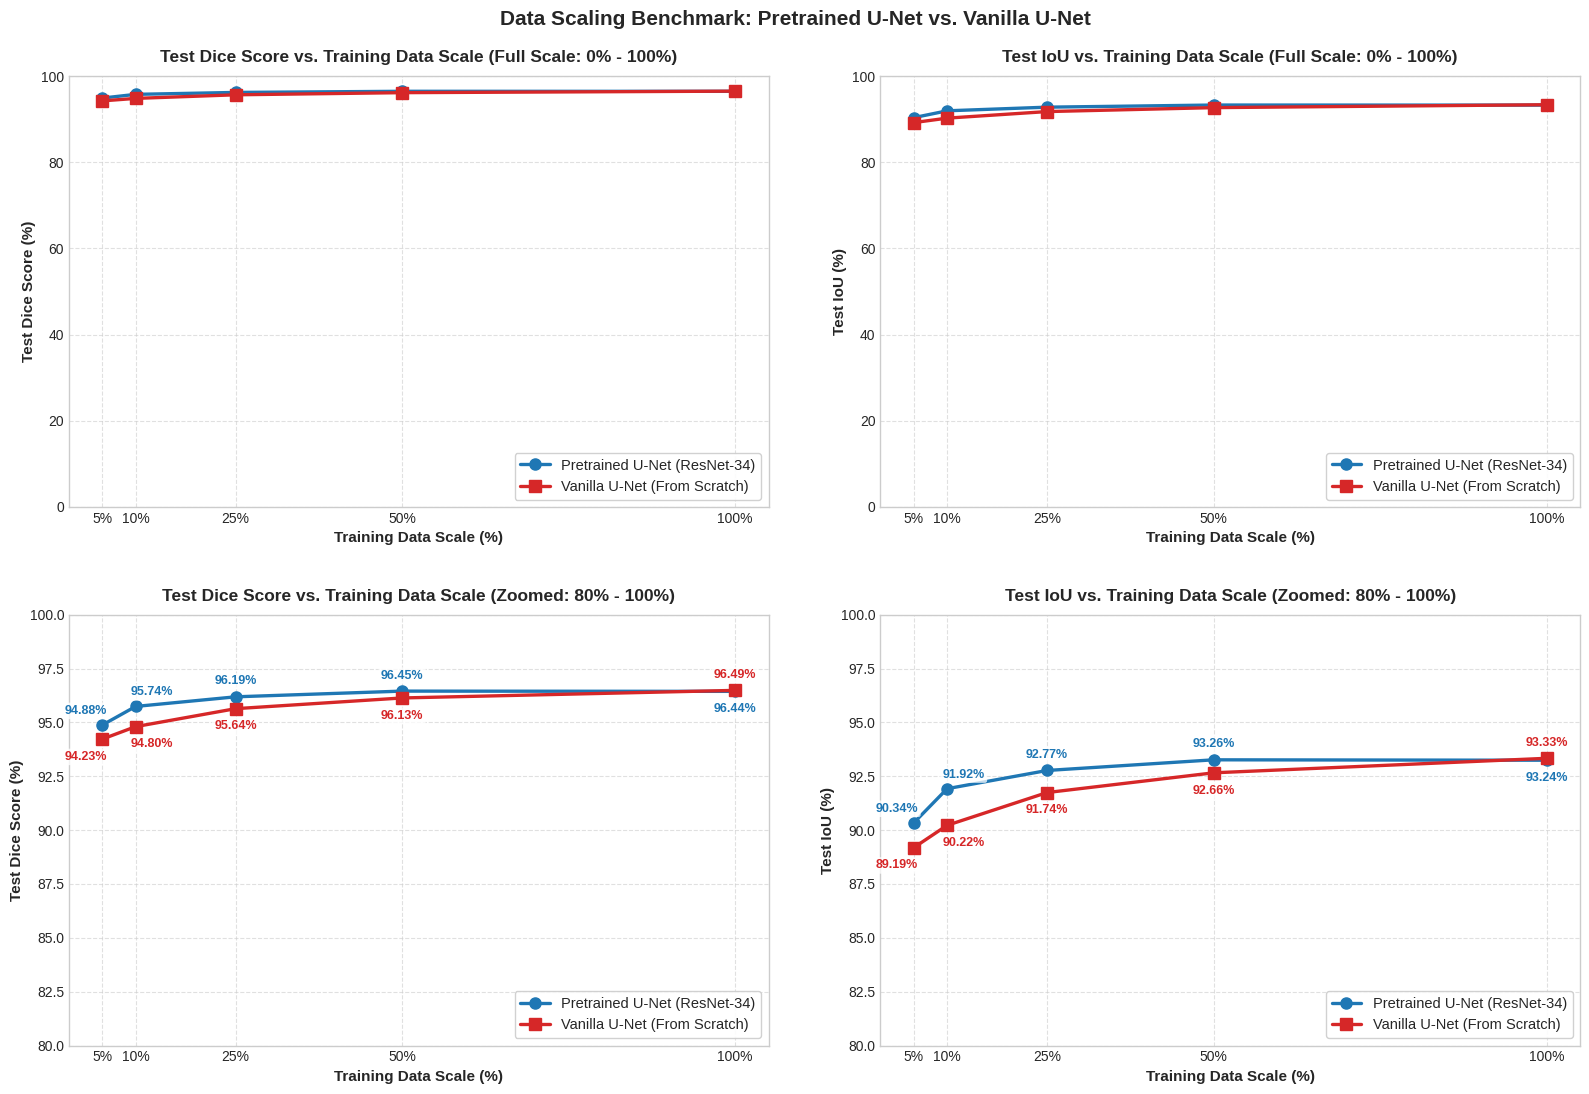

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Fallback to CSV if training cell was not executed in the current session
if 'df_res' not in locals() and os.path.exists('data_scaling_benchmark_results.csv'):
    df_res = pd.read_csv('data_scaling_benchmark_results.csv')

# Configure publication aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

colors = {
    'Pretrained U-Net (ResNet-34)': '#1f77b4',
    'Vanilla U-Net (From Scratch)': '#d62728'
}
markers = {
    'Pretrained U-Net (ResNet-34)': 'o',
    'Vanilla U-Net (From Scratch)': 's'
}

ratios = [5, 10, 25, 50, 100]
x_tick_labels = ['5%', '10%', '25%', '50%', '100%']

configs = [
    (0, 0, 'test_dice', (0, 100), 'Test Dice Score vs. Training Data Scale (Full Scale: 0% - 100%)', 'Test Dice Score (%)'),
    (0, 1, 'test_iou', (0, 100), 'Test IoU vs. Training Data Scale (Full Scale: 0% - 100%)', 'Test IoU (%)'),
    (1, 0, 'test_dice', (80, 100), 'Test Dice Score vs. Training Data Scale (Zoomed: 80% - 100%)', 'Test Dice Score (%)'),
    (1, 1, 'test_iou', (80, 100), 'Test IoU vs. Training Data Scale (Zoomed: 80% - 100%)', 'Test IoU (%)')
]

for row, col, metric, y_lim, title, ylabel in configs:
    ax = axes[row, col]
    for m_name, group in df_res.groupby('model'):
        group_sorted = group.sort_values('ratio')
        color = colors.get(m_name, '#333333')
        marker = markers.get(m_name, 'o')
        ax.plot(
            group_sorted['ratio'],
            group_sorted[metric] * 100,
            marker=marker,
            linewidth=2.4,
            markersize=8,
            color=color,
            label=m_name
        )

    if y_lim == (80, 100):
        p_data = df_res[df_res['model'].str.contains('Pretrained')].set_index('ratio')[metric] * 100
        v_data = df_res[df_res['model'].str.contains('Vanilla')].set_index('ratio')[metric] * 100
        offset_map = {
            5:   {'higher': (-12, 8),  'lower': (-12, -15)},
            10:  {'higher': (12, 8),   'lower': (12, -15)},
            25:  {'higher': (0, 9),    'lower': (0, -15)},
            50:  {'higher': (0, 9),    'lower': (0, -15)},
            100: {'higher': (0, 9),    'lower': (0, -15)}
        }
        for r in ratios:
            p_val = p_data[r]
            v_val = v_data[r]
            p_pos = 'higher' if p_val >= v_val else 'lower'
            v_pos = 'lower' if p_val >= v_val else 'higher'
            ax.annotate(
                f"{p_val:.2f}%",
                (r, p_val),
                textcoords="offset points",
                xytext=offset_map[r][p_pos],
                ha='center',
                fontsize=9,
                fontweight='bold',
                color=colors['Pretrained U-Net (ResNet-34)'],
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.75)
            )
            ax.annotate(
                f"{v_val:.2f}%",
                (r, v_val),
                textcoords="offset points",
                xytext=offset_map[r][v_pos],
                ha='center',
                fontsize=9,
                fontweight='bold',
                color=colors['Vanilla U-Net (From Scratch)'],
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.75)
            )

    ax.set_title(title, fontsize=12.5, fontweight='bold', pad=10)
    ax.set_xlabel('Training Data Scale (%)', fontsize=11, fontweight='semibold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='semibold')
    ax.set_xticks(ratios)
    ax.set_xticklabels(x_tick_labels, fontsize=10)
    ax.set_xlim(0, 105)
    ax.set_ylim(y_lim)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10.5, loc='lower right', frameon=True, framealpha=0.9)

plt.suptitle('Data Scaling Benchmark: Pretrained U-Net vs. Vanilla U-Net', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.25, wspace=0.16)
plt.savefig('data_scaling_comparison.png', dpi=300)
plt.show()


### 10. Qualitative Prediction Matrix Visualization
Displays side-by-side visual segmentation results on independent test cases.

>>> Successfully loaded 10 model checkpoints!


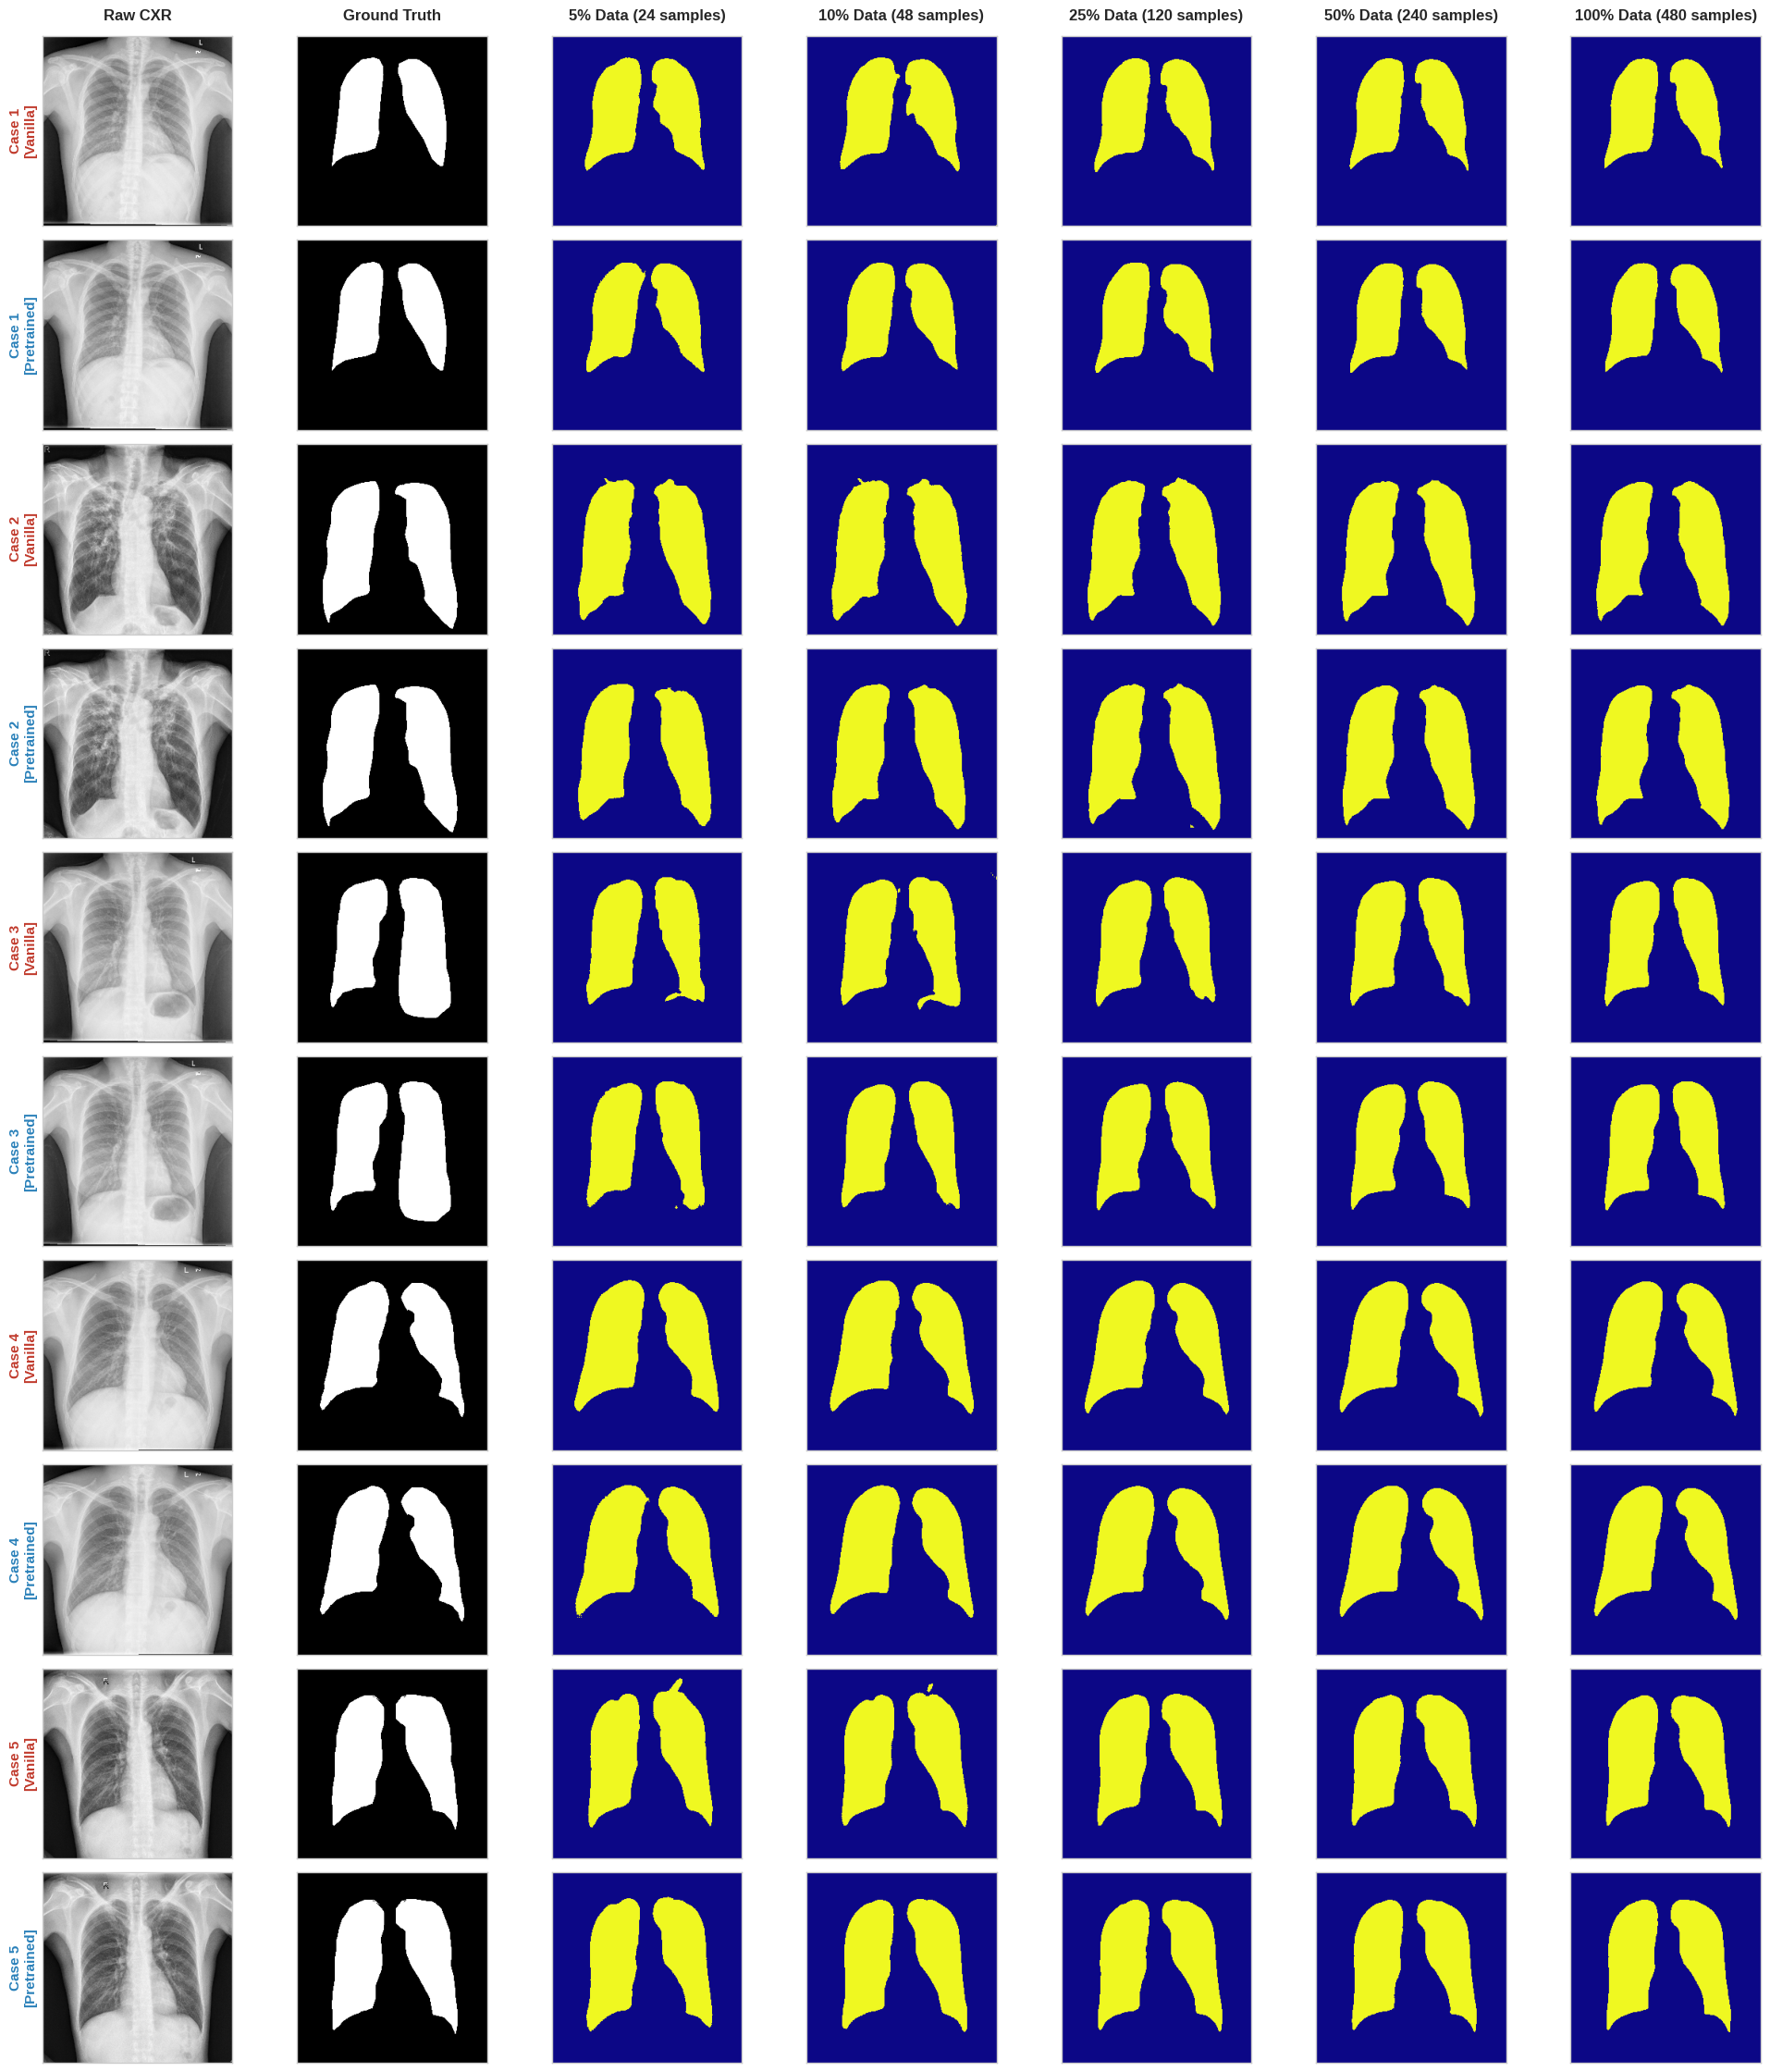

>>> Qualitative comparative matrix exported successfully: qualitative_comparison.png


In [10]:
import matplotlib.pyplot as plt
import torch
import cv2
import numpy as np
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df_test = pd.read_csv('splits/test_fixed_20pct.csv')
transforms_infer = get_transforms(img_size=256, is_train=False)

# 1. Select 5 representative clinical test cases
sample_indices = [5, 18, 32, 45, 60]
ratios = [5, 10, 25, 50, 100]

# 2. Load 10 checkpoints into GPU memory
models_v = {}
models_p = {}
for r in ratios:
    # Vanilla U-Net (From scratch)
    m_v = build_model('vanilla_unet', 'none').to(device)
    m_v.load_state_dict(torch.load(f'checkpoints/vanilla_unet_{r}pct.pth', map_location=device))
    m_v.eval()
    models_v[r] = m_v

    # Pretrained U-Net (ResNet-34)
    m_p = build_model('unet', 'resnet34').to(device)
    m_p.load_state_dict(torch.load(f'checkpoints/unet_{r}pct.pth', map_location=device))
    m_p.eval()
    models_p[r] = m_p

print(">>> Successfully loaded 10 model checkpoints!")

# 3. Grid setup: 5 patients x 2 rows = 10 rows, 7 columns
# Columns: [Raw CXR, Ground Truth, 5%, 10%, 25%, 50%, 100%]
col_titles = ['Raw CXR', 'Ground Truth', '5% Data (24 samples)', '10% Data (48 samples)', '25% Data (120 samples)', '50% Data (240 samples)', '100% Data (480 samples)']
n_samples = len(sample_indices)
fig, axes = plt.subplots(n_samples * 2, 7, figsize=(20, 4.5 * n_samples))

# Set top column titles
for col_idx, title in enumerate(col_titles):
    axes[0, col_idx].set_title(title, fontsize=12, fontweight='bold', pad=12)

for i, s_idx in enumerate(sample_indices):
    row_v = i * 2      # Vanilla row
    row_p = i * 2 + 1  # Pretrained row

    row_data = df_test.iloc[s_idx]
    img_raw = cv2.imread(row_data['image_path'])
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    mask_gt = cv2.imread(row_data['mask_path'], cv2.IMREAD_GRAYSCALE)
    mask_gt = (mask_gt > 127).astype(np.float32)

    t_img = transforms_infer(image=img_rgb)['image'].unsqueeze(0).to(device)

    # Display Raw CXR and Ground Truth for both rows
    img_disp = cv2.resize(img_rgb, (256, 256))
    mask_disp = cv2.resize(mask_gt, (256, 256))

    axes[row_v, 0].imshow(img_disp)
    axes[row_v, 1].imshow(mask_disp, cmap='gray')
    axes[row_p, 0].imshow(img_disp)
    axes[row_p, 1].imshow(mask_disp, cmap='gray')

    # Set left row labels
    axes[row_v, 0].set_ylabel(f'Case {i+1}\n[Vanilla]', fontsize=11, fontweight='bold', color='#c0392b')
    axes[row_p, 0].set_ylabel(f'Case {i+1}\n[Pretrained]', fontsize=11, fontweight='bold', color='#2980b9')

    # Predict and render across 5 data scale ratios for both models
    with torch.no_grad():
        for c_idx, r in enumerate(ratios, start=2):
            pred_v = (torch.sigmoid(models_v[r](t_img)) > 0.5).squeeze().cpu().numpy()
            pred_p = (torch.sigmoid(models_p[r](t_img)) > 0.5).squeeze().cpu().numpy()

            axes[row_v, c_idx].imshow(pred_v, cmap='plasma')
            axes[row_p, c_idx].imshow(pred_p, cmap='plasma')

    # Disable axis ticks for clean visualization
    for c in range(7):
        axes[row_v, c].set_xticks([])
        axes[row_v, c].set_yticks([])
        axes[row_p, c].set_xticks([])
        axes[row_p, c].set_yticks([])

plt.tight_layout()
plt.savefig('qualitative_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(">>> Qualitative comparative matrix exported successfully: qualitative_comparison.png")
